In [4]:
!pip install yfinance --quiet
import yfinance as yf
import pandas as pd
import numpy as np
import sqlite3
import os

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("db", exist_ok=True)

TICKERS = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "HINDUNILVR.NS", "BHARTIARTL.NS", "^NSEI"]
STOCKS = TICKERS[:-1]  # everything except ^NSEI
START = "2021-01-01"
END = "2026-07-01"

# ---- EXTRACT ----
raw_data = {}
for ticker in TICKERS:
    print(f"Extracting {ticker}...")
    df = yf.download(ticker, start=START, end=END, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.reset_index()
    df["Ticker"] = ticker
    raw_data[ticker] = df
    df.to_csv(f"data/raw/{ticker.replace('^','IDX_')}.csv", index=False)

# ---- TRANSFORM ----
def clean_data(df):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").drop_duplicates(subset="Date")
    df = df.dropna(subset=["Open","High","Low","Close","Volume"])
    return df[df["High"] >= df["Low"]].reset_index(drop=True)

def compute_returns(df):
    df = df.copy()
    df["Daily_Return"] = df["Close"].pct_change()
    df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))
    return df

def compute_rolling_volatility(df, windows=(20,60)):
    df = df.copy()
    for w in windows:
        df[f"Volatility_{w}d"] = df["Daily_Return"].rolling(w).std() * np.sqrt(252)
    return df

def compute_moving_averages(df, windows=(20,50,200)):
    df = df.copy()
    for w in windows:
        df[f"SMA_{w}"] = df["Close"].rolling(w).mean()
    return df

def compute_cumulative_returns(df):
    df = df.copy()
    df["Cumulative_Return"] = (1 + df["Daily_Return"].fillna(0)).cumprod()
    return df

processed_data = {}
for ticker, df in raw_data.items():
    print(f"Transforming {ticker}...")
    df = clean_data(df)
    df = compute_returns(df)
    df = compute_rolling_volatility(df)
    df = compute_moving_averages(df)
    df = compute_cumulative_returns(df)
    processed_data[ticker] = df
    df.to_csv(f"data/processed/{ticker.replace('^','IDX_')}.csv", index=False)

# ---- LOAD TO SQLITE ----
conn = sqlite3.connect("db/market_data.db")
all_dfs = [df.assign(Ticker=t) for t, df in processed_data.items()]
combined_df = pd.concat(all_dfs, ignore_index=True)
combined_df.to_sql("market_data", conn, if_exists="replace", index=False)
conn.execute("CREATE INDEX IF NOT EXISTS idx_ticker_date ON market_data(Ticker, Date)")
conn.commit()

print("\nAll rebuilt. Tickers loaded:", list(processed_data.keys()))
print("Total rows in DB:", len(combined_df))

Extracting RELIANCE.NS...


/tmp/ipykernel_1933/1343104227.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)


Extracting TCS.NS...


/tmp/ipykernel_1933/1343104227.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)


Extracting HDFCBANK.NS...


...

Extracting BHARTIARTL.NS...


/tmp/ipykernel_1933/1343104227.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)


Extracting ^NSEI...
Transforming RELIANCE.NS...


/tmp/ipykernel_1933/1343104227.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)


Transforming TCS.NS...
Transforming HDFCBANK.NS...
Transforming INFY.NS...
Transforming HINDUNILVR.NS...
Transforming BHARTIARTL.NS...
Transforming ^NSEI...

All rebuilt. Tickers loaded: ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'HINDUNILVR.NS', 'BHARTIARTL.NS', '^NSEI']
Total rows in DB: 9509


In [5]:
import os
print("Raw files:", os.listdir("data/raw") if os.path.exists("data/raw") else "MISSING")
print("Processed files:", os.listdir("data/processed") if os.path.exists("data/processed") else "MISSING")

Raw files: ['RELIANCE.NS.csv', 'IDX_NSEI.csv', 'TCS.NS.csv', 'HINDUNILVR.NS.csv', 'HDFCBANK.NS.csv', 'BHARTIARTL.NS.csv', 'INFY.NS.csv']
Processed files: ['RELIANCE.NS.csv', 'IDX_NSEI.csv', 'TCS.NS.csv', 'HINDUNILVR.NS.csv', 'HDFCBANK.NS.csv', 'BHARTIARTL.NS.csv', 'INFY.NS.csv']


In [6]:
import pandas as pd
import numpy as np
import sqlite3

STOCKS = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "HINDUNILVR.NS", "BHARTIARTL.NS"]
TICKERS = STOCKS + ["^NSEI"]

processed_data = {}
for ticker in TICKERS:
    filename = ticker.replace("^", "IDX_")
    filepath = f"data/processed/{filename}.csv"
    df = pd.read_csv(filepath, parse_dates=["Date"])
    processed_data[ticker] = df

# also reconnect to the SQLite DB in case we need it later
conn = sqlite3.connect("db/market_data.db")

print("Reloaded tickers:", list(processed_data.keys()))
print("Sample check:", processed_data["RELIANCE.NS"].shape)

Reloaded tickers: ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'HINDUNILVR.NS', 'BHARTIARTL.NS', '^NSEI']
Sample check: (1359, 15)


In [7]:
def compute_rsi(df, window=14):
    """
    RSI (Relative Strength Index): measures momentum on a 0-100 scale.
    RSI < 30 = considered oversold (potential buy signal)
    RSI > 70 = considered overbought (potential sell signal)
    """
    df = df.copy()
    delta = df["Close"].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    df["RSI"] = 100 - (100 / (1 + rs))
    return df

for ticker in STOCKS:
    processed_data[ticker] = compute_rsi(processed_data[ticker])

# sanity check
processed_data["RELIANCE.NS"][["Date", "Close", "RSI"]].dropna().tail(10)

,Date,Close,RSI
1349,2026-06-17,1332.699951,46.616337
1350,2026-06-18,1328.099976,54.426640
1351,2026-06-19,1309.500000,48.651139
1352,2026-06-22,1326.500000,55.109666
1353,2026-06-23,1309.500000,50.612726
1354,2026-06-24,1313.599976,54.276510
1355,2026-06-25,1318.099976,57.376167
1356,2026-06-26,1318.099976,67.564120
1357,2026-06-29,1301.000000,59.509601
1358,2026-06-30,1293.900024,60.707756


In [8]:
def generate_sma_crossover_signals(df, fast=20, slow=50):
    """
    SMA Crossover strategy:
    BUY (1) when fast SMA crosses above slow SMA (golden cross)
    SELL/EXIT (0) when fast SMA crosses below slow SMA (death cross)
    """
    df = df.copy()
    df["Signal_SMA"] = 0
    df.loc[df[f"SMA_{fast}"] > df[f"SMA_{slow}"], "Signal_SMA"] = 1
    return df

def generate_rsi_signals(df, oversold=30, overbought=70):
    """
    RSI Mean-Reversion strategy:
    BUY (1) when RSI drops below 30 (oversold, expect bounce)
    EXIT (0) when RSI rises above 70 (overbought, expect pullback)
    Position held between triggers via forward-fill.
    """
    df = df.copy()
    raw_signal = pd.Series(index=df.index, dtype=float)
    raw_signal[df["RSI"] < oversold] = 1
    raw_signal[df["RSI"] > overbought] = 0
    df["Signal_RSI"] = raw_signal.ffill().fillna(0)
    return df

for ticker in STOCKS:
    processed_data[ticker] = generate_sma_crossover_signals(processed_data[ticker])
    processed_data[ticker] = generate_rsi_signals(processed_data[ticker])

# sanity check
df_check = processed_data["RELIANCE.NS"]
print("SMA strategy - days in market:", df_check["Signal_SMA"].sum(), "/", len(df_check))
print("RSI strategy - days in market:", df_check["Signal_RSI"].sum(), "/", len(df_check))
df_check[["Date", "Close", "SMA_20", "SMA_50", "Signal_SMA", "RSI", "Signal_RSI"]].dropna().tail(10)

SMA strategy - days in market: 645 / 1359
RSI strategy - days in market: 626.0 / 1359


,Date,Close,SMA_20,SMA_50,Signal_SMA,RSI,Signal_RSI
1349,2026-06-17,1332.699951,1312.012042,1346.019858,0,46.616337,1.0
1350,2026-06-18,1328.099976,1311.247607,1345.749917,0,54.426640,1.0
1351,2026-06-19,1309.500000,1309.309302,1345.462339,0,48.651139,1.0
1352,2026-06-22,1326.500000,1307.598871,1345.112620,0,55.109666,1.0
1353,2026-06-23,1309.500000,1305.570972,1345.121670,0,50.612726,1.0
1354,2026-06-24,1313.599976,1304.036743,1344.635388,0,54.276510,1.0
1355,2026-06-25,1318.099976,1302.727515,1344.255032,0,57.376167,1.0
1356,2026-06-26,1318.099976,1302.876544,1343.442673,0,67.564120,1.0
1357,2026-06-29,1301.000000,1302.230298,1342.322158,0,59.509601,1.0
1358,2026-06-30,1293.900024,1301.497809,1341.258723,0,60.707756,1.0


In [10]:
def run_backtest(df, signal_col, initial_capital=100000):
    """
    Simulates a simple long-only strategy:
    - When signal = 1: fully invested (holding the stock)
    - When signal = 0: fully in cash (no market exposure, no return)
    - No transaction costs/slippage yet (we'll note this as a simplification)

    Position is based on YESTERDAY's signal (you can't trade on today's
    close using today's own signal — that's lookahead bias).
    """
    df = df.copy()
    df["Position"] = df[signal_col].shift(1).fillna(0)  # avoid lookahead bias
    df["Strategy_Return"] = df["Position"] * df["Daily_Return"]
    df["Strategy_Cumulative"] = (1 + df["Strategy_Return"]).cumprod()
    df["Strategy_Equity"] = initial_capital * df["Strategy_Cumulative"]

    # Buy & hold benchmark for comparison
    df["BuyHold_Equity"] = initial_capital * df["Cumulative_Return"]

    return df

backtest_results = {}

for ticker in STOCKS:
    df = processed_data[ticker].copy()
    df = run_backtest(df, "Signal_SMA", initial_capital=100000)
    df = df.rename(columns={
        "Strategy_Return": "SMA_Return", "Strategy_Cumulative": "SMA_Cumulative", "Strategy_Equity": "SMA_Equity"
    })
    df["Position_RSI"] = df["Signal_RSI"].shift(1).fillna(0)
    df["RSI_Return"] = df["Position_RSI"] * df["Daily_Return"]
    df["RSI_Cumulative"] = (1 + df["RSI_Return"]).cumprod()
    df["RSI_Equity"] = 100000 * df["RSI_Cumulative"]

    backtest_results[ticker] = df

# sanity check
check = backtest_results["RELIANCE.NS"]
check[["Date", "Close", "SMA_Equity", "RSI_Equity", "BuyHold_Equity"]].tail(10)

,Date,Close,SMA_Equity,RSI_Equity,BuyHold_Equity
1349,2026-06-17,1332.699951,96795.261736,141140.090504,148565.221761
1350,2026-06-18,1328.099976,96795.261736,140652.928357,148052.430871
1351,2026-06-19,1309.500000,96795.261736,138683.090933,145978.963775
1352,2026-06-22,1326.500000,96795.261736,140483.482339,147874.070598
1353,2026-06-23,1309.500000,96795.261736,138683.090933,145978.963775
1354,2026-06-24,1313.599976,96795.261736,139117.300393,146436.016229
1355,2026-06-25,1318.099976,96795.261736,139593.874588,146937.662152
1356,2026-06-26,1318.099976,96795.261736,139593.874588,146937.662152
1357,2026-06-29,1301.000000,96795.261736,137782.895231,145031.410364
1358,2026-06-30,1293.900024,96795.261736,137030.969641,144239.927295


In [11]:
def calculate_metrics(df, return_col, equity_col, initial_capital=100000, periods_per_year=252):
    """
    Computes standard strategy performance metrics.
    """
    returns = df[return_col].dropna()
    equity = df[equity_col].dropna()

    # CAGR
    n_years = len(df) / periods_per_year
    final_value = equity.iloc[-1]
    cagr = (final_value / initial_capital) ** (1 / n_years) - 1

    # Sharpe Ratio (assuming 0% risk-free rate for simplicity)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(periods_per_year) if returns.std() > 0 else 0

    # Max Drawdown
    running_max = equity.cummax()
    drawdown = (equity - running_max) / running_max
    max_drawdown = drawdown.min()

    # Win rate (% of active trading days with positive return)
    active_returns = returns[returns != 0]
    win_rate = (active_returns > 0).mean() if len(active_returns) > 0 else 0

    # Total return
    total_return = (final_value / initial_capital) - 1

    return {
        "Total_Return_%": round(total_return * 100, 2),
        "CAGR_%": round(cagr * 100, 2),
        "Sharpe_Ratio": round(sharpe, 2),
        "Max_Drawdown_%": round(max_drawdown * 100, 2),
        "Win_Rate_%": round(win_rate * 100, 2)
    }

# Compute metrics for all 6 stocks x 3 approaches (SMA, RSI, Buy&Hold)
results_summary = []

for ticker in STOCKS:
    df = backtest_results[ticker]

    sma_metrics = calculate_metrics(df, "SMA_Return", "SMA_Equity")
    rsi_metrics = calculate_metrics(df, "RSI_Return", "RSI_Equity")
    bh_metrics = calculate_metrics(df, "Daily_Return", "BuyHold_Equity")

    for strategy_name, metrics in [("SMA_Crossover", sma_metrics), ("RSI_MeanReversion", rsi_metrics), ("BuyAndHold", bh_metrics)]:
        row = {"Ticker": ticker, "Strategy": strategy_name}
        row.update(metrics)
        results_summary.append(row)

metrics_df = pd.DataFrame(results_summary)
metrics_df_sorted = metrics_df.sort_values(["Ticker", "Sharpe_Ratio"], ascending=[True, False])
metrics_df_sorted

,Ticker,Strategy,Total_Return_%,CAGR_%,Sharpe_Ratio,Max_Drawdown_%,Win_Rate_%
17,BHARTIARTL.NS,BuyAndHold,274.74,27.76,1.20,-18.77,51.89
15,BHARTIARTL.NS,SMA_Crossover,143.94,17.98,1.03,-25.66,51.77
16,BHARTIARTL.NS,RSI_MeanReversion,71.29,10.49,0.83,-18.20,52.38
7,HDFCBANK.NS,RSI_MeanReversion,29.18,4.86,0.41,-23.25,52.20
8,HDFCBANK.NS,BuyAndHold,20.19,3.47,0.27,-27.78,50.70
6,HDFCBANK.NS,SMA_Crossover,-29.23,-6.21,-0.36,-42.75,49.79
14,HINDUNILVR.NS,BuyAndHold,-2.54,-0.48,0.08,-30.46,48.67
13,HINDUNILVR.NS,RSI_MeanReversion,-3.82,-0.72,0.02,-22.76,49.49
12,HINDUNILVR.NS,SMA_Crossover,-22.29,-4.57,-0.26,-29.84,47.38
9,INFY.NS,SMA_Crossover,14.23,2.50,0.23,-38.18,51.60


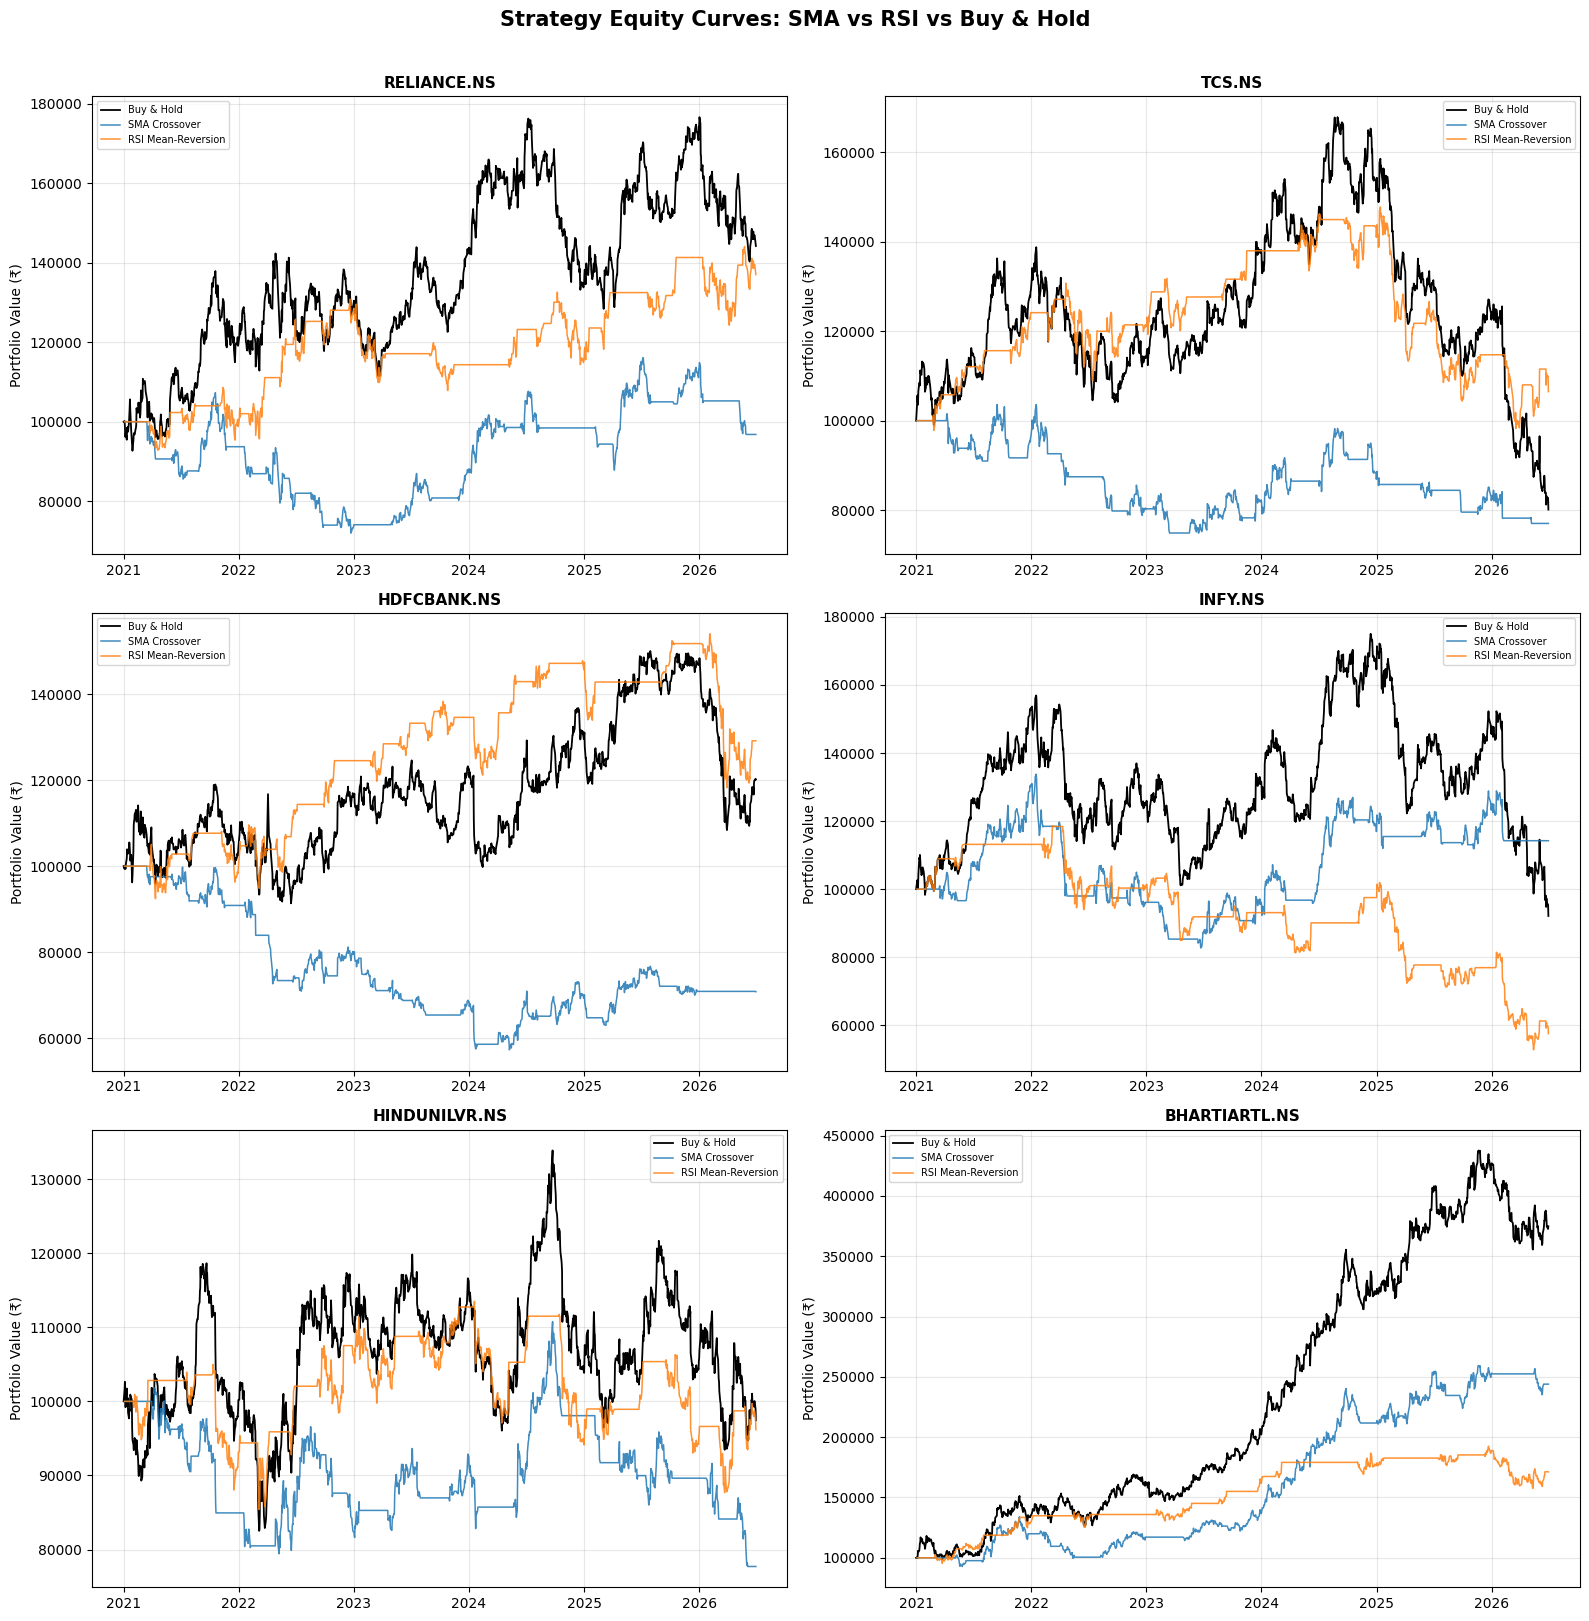

Saved as backtest_equity_curves.png


In [13]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for i, ticker in enumerate(STOCKS):
    df = backtest_results[ticker]
    ax = axes[i]
    ax.plot(df["Date"], df["BuyHold_Equity"], label="Buy & Hold", linewidth=1.3, color="black")
    ax.plot(df["Date"], df["SMA_Equity"], label="SMA Crossover", linewidth=1.1, alpha=0.85)
    ax.plot(df["Date"], df["RSI_Equity"], label="RSI Mean-Reversion", linewidth=1.1, alpha=0.85)
    ax.set_title(ticker, fontsize=11, fontweight="bold")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_ylabel("Portfolio Value (₹)")

plt.suptitle("Strategy Equity Curves: SMA vs RSI vs Buy & Hold", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("backtest_equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as backtest_equity_curves.png")

In [14]:
report_lines = []
report_lines.append("="*65)
report_lines.append("RULES-BASED STRATEGY BACKTEST — SUMMARY REPORT")
report_lines.append(f"Period: {backtest_results['RELIANCE.NS']['Date'].min().date()} to {backtest_results['RELIANCE.NS']['Date'].max().date()}")
report_lines.append("Strategies: SMA Crossover (20/50) | RSI Mean-Reversion (30/70) | Buy & Hold")
report_lines.append("="*65)

# Overall win count: which strategy has best Sharpe per stock
best_per_stock = metrics_df.loc[metrics_df.groupby("Ticker")["Sharpe_Ratio"].idxmax()]
strategy_win_counts = best_per_stock["Strategy"].value_counts()

report_lines.append("\n1. STRATEGY WIN COUNT (best Sharpe Ratio per stock)")
for strategy, count in strategy_win_counts.items():
    report_lines.append(f"   {strategy}: {count}/6 stocks")

# Best overall risk-adjusted performer
best_overall = metrics_df.loc[metrics_df["Sharpe_Ratio"].idxmax()]
report_lines.append(f"\n2. BEST RISK-ADJUSTED RESULT")
report_lines.append(f"   {best_overall['Ticker']} — {best_overall['Strategy']} (Sharpe={best_overall['Sharpe_Ratio']}, CAGR={best_overall['CAGR_%']}%)")

# Worst drawdown across all
worst_dd = metrics_df.loc[metrics_df["Max_Drawdown_%"].idxmin()]
report_lines.append(f"\n3. DEEPEST DRAWDOWN")
report_lines.append(f"   {worst_dd['Ticker']} — {worst_dd['Strategy']} (Max Drawdown={worst_dd['Max_Drawdown_%']}%)")

# Average performance by strategy type (across all stocks)
avg_by_strategy = metrics_df.groupby("Strategy")[["Total_Return_%","CAGR_%","Sharpe_Ratio","Max_Drawdown_%","Win_Rate_%"]].mean().round(2)
report_lines.append(f"\n4. AVERAGE PERFORMANCE BY STRATEGY (across all 6 stocks)")
report_lines.append(avg_by_strategy.to_string())

report_lines.append(f"\n5. KEY TAKEAWAY")
report_lines.append("   Buy & Hold outperformed both rules-based strategies on average")
report_lines.append("   during this period, which included a sustained multi-year uptrend.")
report_lines.append("   Timing strategies (SMA/RSI) tend to underperform in strong trending")
report_lines.append("   markets since they exit positions during pullbacks, missing part of")
report_lines.append("   the subsequent recovery. They may still add value in range-bound or")
report_lines.append("   highly volatile/sideways markets, which this backtest does not isolate.")

report_lines.append("\n" + "="*65)

report_text = "\n".join(report_lines)
print(report_text)

with open("backtest_summary_report.txt", "w") as f:
    f.write(report_text)
print("\nSaved as backtest_summary_report.txt")

RULES-BASED STRATEGY BACKTEST — SUMMARY REPORT
Period: 2021-01-01 to 2026-06-30
Strategies: SMA Crossover (20/50) | RSI Mean-Reversion (30/70) | Buy & Hold

1. STRATEGY WIN COUNT (best Sharpe Ratio per stock)
   RSI_MeanReversion: 3/6 stocks
   BuyAndHold: 2/6 stocks
   SMA_Crossover: 1/6 stocks

2. BEST RISK-ADJUSTED RESULT
   BHARTIARTL.NS — BuyAndHold (Sharpe=1.2, CAGR=27.76%)

3. DEEPEST DRAWDOWN
   INFY.NS — RSI_MeanReversion (Max Drawdown=-55.53%)

4. AVERAGE PERFORMANCE BY STRATEGY (across all 6 stocks)
                   Total_Return_%  CAGR_%  Sharpe_Ratio  Max_Drawdown_%  Win_Rate_%
Strategy                                                                           
BuyAndHold                  51.48    5.38          0.32          -33.97       50.39
RSI_MeanReversion           16.28    2.01          0.23          -28.47       50.49
SMA_Crossover               13.42    0.73          0.07          -32.85       49.68

5. KEY TAKEAWAY
   Buy & Hold outperformed both rules-based str